In [ ]:
# default_exp electricmachinepu

In [ ]:
#hide
from nbdev.showdoc import *

# pmsm per unit analysis

This script analyzes the performance of pmsm in per unit scale. The following equations are used for this analysis

In [ ]:
#export
import numpy as np
import matplotlib.pyplot as plt


Ideal PMSM model in p.u ignoring resistance

$V = \omega \sqrt{ (\lambda_m - L_d i_d )^2 + (L_q i_q )^2 }$  
$T = \lambda_m I \cos(\gamma)$  
$i_d = I \sin(\gamma)$  
$i_q = I \cos(\gamma)$

## Class: SPM
spm class provides the ideal per unit capability of the machine defined by two parameters   
flux linkage ($\lambda_m$) = phi_m  
inductance ($L_d = L_q = L$) = lpu    
MTPA operation of spm requires $\gamma = 0$   
Considering the above machine specific constraints, valid combinations of $ \lambda_m, L_d, L_q$ parameters are bound by the following expression at base speed.    
$1 = \sqrt{\lambda_m^2 + L^2 }$     
spm machine is characterized here by just $L$. $\lambda_m$ is calculated using the above constraint

In [ ]:
#export
class spm():
    def __init__(self, lpu):
        self.lpu = lpu
        self.phi_m = np.sqrt(1-lpu**2)
        self.Vb = 0
        self.Pb = 0
        self.wb = 0
        self.speed = []
        self.torque = []
        self.voltage = []
        self.current = []
        self.gamma = []
        self.power = []
        self.values = dict.fromkeys(['speed', 'torque', 'power'])
            
    def motor_puprofile(self, gamma_limit = 85):
        """ this method calculates the per unit profile of the machine with current angle limit of 85 degrees
        """
        gamma_deg = 0
        gamma = gamma_deg*np.pi/180
        # constant torque region
        for o in np.arange(0,1.1,0.1):
            v = o * np.sqrt( (self.phi_m - np.sin(gamma))**2 + (self.lpu * np.cos(gamma))**2 )
            t = self.phi_m * np.cos(gamma)
            p = t*o
            self.speed.append(o)
            self.voltage.append(v)
            self.gamma.append(gamma)
            self.torque.append(t)
            self.power.append(p)
        # constant power region
        for gamma_deg in range(1,85):
            gamma = gamma_deg*np.pi/180
            o = 1/np.sqrt( (self.phi_m - np.sin(gamma)*self.lpu)**2 + (self.lpu * np.cos(gamma))**2 )
            t = self.phi_m * np.cos(gamma)
            p = t*o
            self.speed.append(o)
            self.voltage.append(v)
            self.gamma.append(gamma_deg)
            self.torque.append(t)
            self.power.append(p)
    
    def motor_profile(self, Vb, Pb, wb):
        """This method takes Vb, Pb, wb as the base values for line voltage, KVA rating of the machine, base speed respectively
        """
        self.Vb = Vb
        self.Pb = Pb
        self.wb = wb
        Tb = Pb/(2*np.pi*wb/60)
        self.values['speed'] = np.array(self.speed)*wb
        self.values['torque'] = np.array(self.torque)*Tb
        self.values['power'] = np.array(self.power)*Pb
        
    
    def plot_puprofile(self):
        """ plots the motor performance profile in p.u
        """
        fig, axs = plt.subplots(3)
        fig.set_figheight(8)
        axs[0].plot(self.speed, self.torque)
        axs[0].set_title('torque vs speed')
        axs[1].plot(self.speed, self.power)
        axs[1].set_title('power vs speed')
        axs[2].plot(self.speed, self.gamma)
        axs[2].set_title('gamma vs speed')
        
        # Hide x labels and tick labels for top plots and y ticks for right plots.
        for ax in axs.flat:
            ax.label_outer()
        
        plt.tight_layout()
        plt.show()
    
    def plot_profile(self):
        """ plots the motor performance profile in actual values
        """       
        fig, axs = plt.subplots(3)
        fig.set_figheight(8)
        axs[0].plot(self.values['speed'], self.values['torque'])
        axs[0].set_title('torque vs speed')
        axs[1].plot(self.values['speed'], self.values['power'])
        axs[1].set_title('power vs speed')
        axs[2].plot(self.values['speed'], self.gamma)
        axs[2].set_title('gamma vs speed')
        
        # Hide x labels and tick labels for top plots and y ticks for right plots.
        for ax in axs.flat:
            ax.label_outer()
        
        plt.tight_layout()
        plt.show()

In [ ]:
show_doc(spm.motor_puprofile)
show_doc(spm.motor_profile)
show_doc(spm.plot_puprofile)
show_doc(spm.plot_profile)

<h4 id="spm.motor_puprofile" class="doc_header"><code>spm.motor_puprofile</code><a href="__main__.py#L17" class="source_link" style="float:right">[source]</a></h4>

> <code>spm.motor_puprofile</code>(**`gamma_limit`**=*`85`*)

this method calculates the per unit profile of the machine with current angle limit of 85 degrees
        

<h4 id="spm.motor_profile" class="doc_header"><code>spm.motor_profile</code><a href="__main__.py#L44" class="source_link" style="float:right">[source]</a></h4>

> <code>spm.motor_profile</code>(**`Vb`**, **`Pb`**, **`wb`**)

This method takes Vb, Pb, wb as the base values for line voltage, KVA rating of the machine, base speed respectively

<h4 id="spm.plot_puprofile" class="doc_header"><code>spm.plot_puprofile</code><a href="__main__.py#L57" class="source_link" style="float:right">[source]</a></h4>

> <code>spm.plot_puprofile</code>()

plots the motor performance profile in p.u
        

<h4 id="spm.plot_profile" class="doc_header"><code>spm.plot_profile</code><a href="__main__.py#L76" class="source_link" style="float:right">[source]</a></h4>

> <code>spm.plot_profile</code>()

plots the motor performance profile in actual values
        

## Usage example

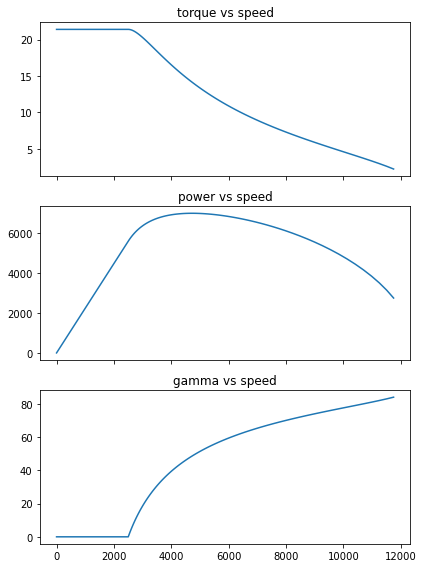

In [ ]:
#hide_output
M1 = spm(0.6)
M1.motor_puprofile()
M1.motor_profile(42, 7000, 2500)
M1.plot_profile()